📥 Fetching NYC Taxi Demand Dataset...

███████████████████████████████████████████████████████
  SCENARIO 1: 24-HOUR WEEKDAY (TUESDAY)
███████████████████████████████████████████████████████

🏙️ CHRONOSLAB v6 (Urban Pulse) — 24H Weekday (Tue) | horizon=24 Hours
   [BASELINE] ETS(Trend=Add, Damped=True, Seasonal=Add, Period=168) ✓
   [ALPHA GATE] Residual Variance: 0.002810
   >>> TRIGGERED: High Volatility. Neural Phase active.
   --- GBR CORRECTOR ---
       GBR trained on 2952 hourly samples.
   --- BiLSTM CORRECTOR ---
       BiLSTM training on 2952 hourly sequences...

   [GATED BLEND]
   GBR  corr=-0.016  → α=0.000  (BLOCKED)
   LSTM corr=0.032  → α=0.000  (BLOCKED)

📊 FINAL DIAGNOSTIC REPORT (URBAN PULSE)
Status:       ✅ SUCCESS
Hybrid Mode:  True
GBR  α=0.000 | LSTM α=0.000
Improvement:  0.00% Points
Stat  MAPE:   5.76%  | Final MAPE:  5.76%
Stat  MAE:    1954.96    | Final MAE:   1954.96


███████████████████████████████████████████████████████
  SCENARIO 2: 24-HOUR WEEKEND (SA

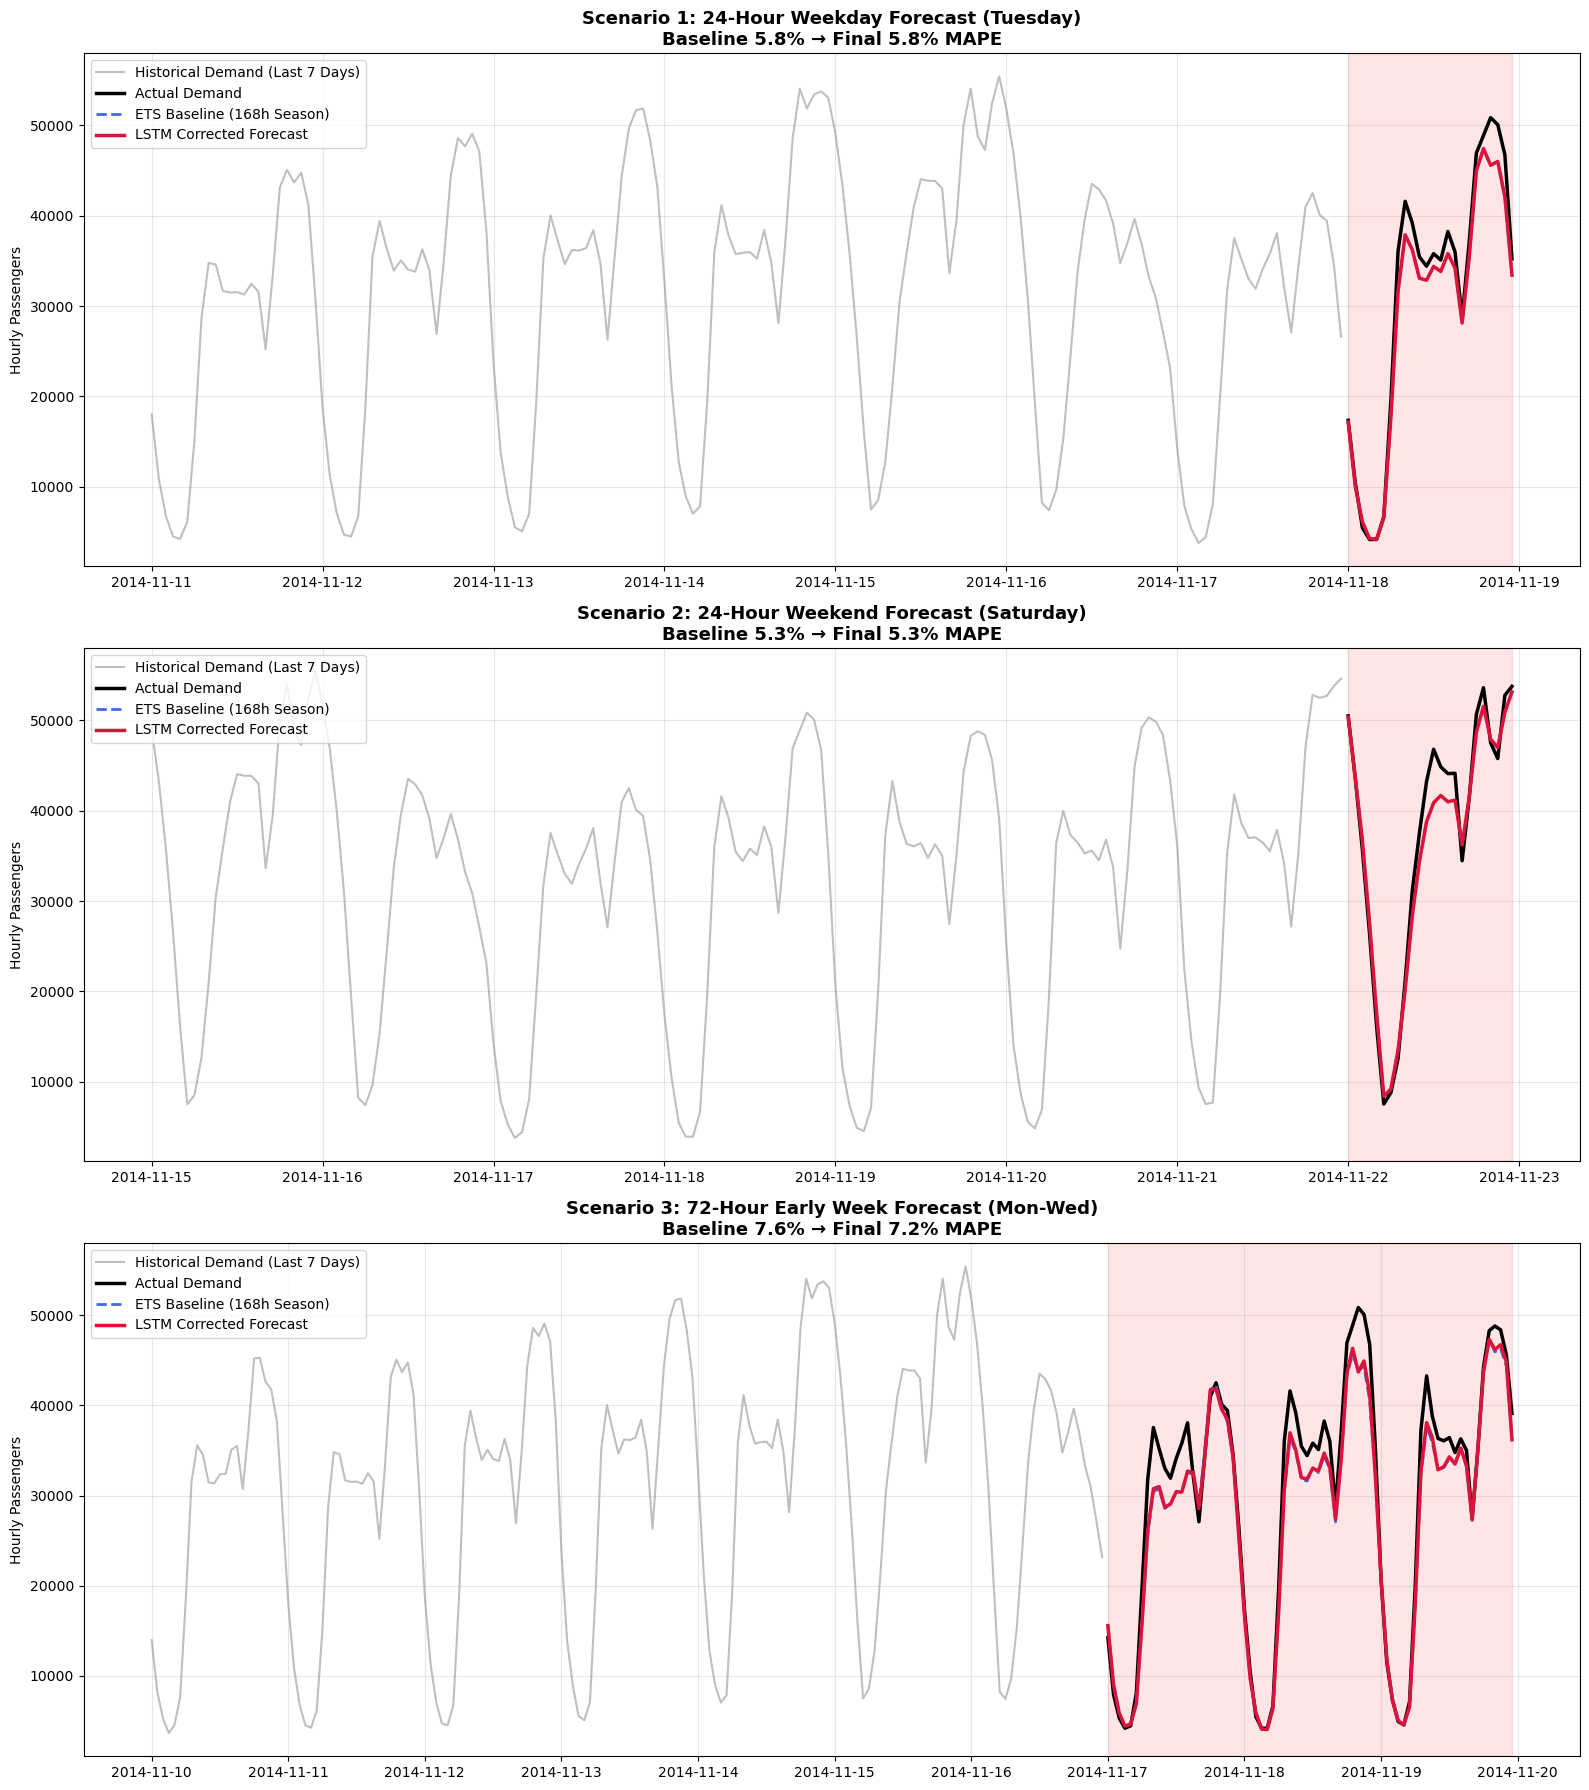

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
import tensorflow as tf

warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

# =========================================================
# MODULE 0: URBAN PREPROCESSING
# =========================================================
def winsorize_series(ts, lower=0.01, upper=0.99):
    return ts.clip(ts.quantile(lower), ts.quantile(upper))

def get_time_features(index):
    hour = index.hour
    dow  = index.dayofweek
    return np.column_stack([
        np.sin(2 * np.pi * hour / 24),
        np.cos(2 * np.pi * hour / 24),
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        ((hour >= 7) & (hour <= 9)).astype(float),
        ((hour >= 17) & (hour <= 19)).astype(float),
        ((hour >= 22) | (hour <= 5)).astype(float),
        (dow >= 5).astype(float),
        hour.astype(float) / 23.0,
        dow.astype(float) / 6.0,
    ])

# =========================================================
# MODULE 1: DAMPED CYCLICAL BASELINE
# =========================================================
def fit_ets_urban(train, period=24):
    return ExponentialSmoothing(
        train, trend='add', damped_trend=True,
        seasonal='add', seasonal_periods=period,
    ).fit(optimized=True)

def safe_forecast(preds):
    arr = np.array(preds, dtype=float)
    if np.any(~np.isfinite(arr)):
        finite_vals = arr[np.isfinite(arr)]
        fill = float(np.median(finite_vals)) if len(finite_vals) > 0 else 0.0
        arr  = np.where(np.isfinite(arr), arr, fill)
    return arr

def get_statistical_forecast(train_log, test_log, period):
    horizon = len(test_log)
    
    # DYNAMIC PRINT FIX
    print(f"   [BASELINE] ETS(Trend=Add, Damped=True, Seasonal=Add, Period={period}) ✓")
    ets = fit_ets_urban(train_log, period)
    raw = safe_forecast(ets.forecast(horizon))
    
    stat_preds = pd.Series(raw, index=test_log.index)
    residuals  = pd.Series(ets.resid.values, index=train_log.index).fillna(0)

    return stat_preds, residuals

# =========================================================
# MODULE 2: STABILIZED GATING
# =========================================================
def check_alpha_breakout(residuals, alpha=0.01):
    res_var = float(np.var(residuals))
    print(f"   [ALPHA GATE] Residual Variance: {res_var:.6f}")
    if res_var > alpha:
        print("   >>> TRIGGERED: High Volatility. Neural Phase active.")
        return True
    return False

def gated_alpha(corrections, residuals_vals, base_alpha=0.40, min_corr=0.05):
    n    = min(len(residuals_vals), len(corrections))
    corr = np.corrcoef(np.array(residuals_vals)[-n:], corrections[-n:])[0, 1]
    
    if np.isnan(corr) or corr <= min_corr:
        return 0.0, float(corr) if not np.isnan(corr) else 0.0
    
    alpha = float(np.clip(base_alpha * corr, 0.05, base_alpha))
    return alpha, float(corr)

# =========================================================
# MODULE 3A: GBR CORRECTOR
# =========================================================
def build_gbr_features(res_vals, time_feats, window_size):
    X, y = [], []
    for i in range(window_size, len(res_vals)):
        lag   = res_vals[i - window_size:i]
        stats = [np.mean(lag), np.std(lag), np.min(lag),
                 np.max(lag), np.median(lag), lag[-1], lag[-2], lag[-3]]
        X.append(np.concatenate([lag, stats, time_feats[i]]))
        y.append(res_vals[i])
    return np.array(X), np.array(y)

def execute_gbr_corrector(residuals, test_actual, stat_preds, horizon, test_index, window_size=24):
    print("   --- GBR CORRECTOR ---")
    smoothed  = residuals.rolling(window=3, min_periods=1).mean()
    full_idx  = smoothed.index.append(test_index)
    tf_arr    = get_time_features(full_idx)

    scaler  = RobustScaler()
    res_sc  = scaler.fit_transform(smoothed.values.reshape(-1, 1)).flatten()

    X, y = build_gbr_features(res_sc, tf_arr, window_size)
    gbr  = GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.02, max_depth=4,
        min_samples_leaf=5, subsample=0.8, random_state=42)
    gbr.fit(X, y)
    print(f"       GBR trained on {len(X)} hourly samples.")

    history = list(res_sc)
    corrs   = []
    for t in range(horizon):
        lag   = np.array(history[-window_size:])
        stats = [np.mean(lag), np.std(lag), np.min(lag),
                 np.max(lag), np.median(lag), lag[-1], lag[-2], lag[-3]]
        row   = np.concatenate([lag, stats, tf_arr[len(smoothed) + t]])
        p_sc  = gbr.predict([row])[0]
        corrs.append(scaler.inverse_transform([[p_sc]])[0, 0])

        actual_val = test_actual.iloc[t] if hasattr(test_actual, 'iloc') else test_actual[t]
        true_r     = actual_val - stat_preds.iloc[t]
        history.append(scaler.transform([[true_r]])[0, 0])

    return np.array(corrs)

# =========================================================
# MODULE 3B: BiLSTM CORRECTOR
# =========================================================
def build_bilstm(window_size, n_tf=10): 
    res_in = Input(shape=(window_size, 1), name='res')
    x = Bidirectional(LSTM(64, activation='tanh', return_sequences=True,
                           kernel_regularizer=regularizers.l2(0.005)))(res_in)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(32, activation='tanh',
                           kernel_regularizer=regularizers.l2(0.005)))(x)
    x = Dropout(0.2)(x)

    tf_in = Input(shape=(n_tf,), name='tf')
    t = Dense(32, activation='relu')(tf_in)
    t = Dense(16, activation='relu')(t)

    m   = Concatenate()([x, t])
    m   = Dense(32, activation='relu')(m)
    m   = Dropout(0.1)(m)
    out = Dense(1)(m)

    model = Model([res_in, tf_in], out)
    model.compile(optimizer=Adam(0.001), loss='huber')
    return model

def execute_lstm_corrector(residuals, test_actual, stat_preds, horizon, test_index, window_size=24, epochs=120):
    print("   --- BiLSTM CORRECTOR ---")
    smoothed  = residuals.rolling(window=3, min_periods=1).mean()
    full_idx  = smoothed.index.append(test_index)
    tf_arr    = get_time_features(full_idx)

    scaler  = RobustScaler()
    res_sc  = scaler.fit_transform(smoothed.values.reshape(-1, 1)).flatten()

    X_r, X_t, y = [], [], []
    for i in range(window_size, len(res_sc)):
        X_r.append(res_sc[i - window_size:i])
        X_t.append(tf_arr[i])
        y.append(res_sc[i])
    X_r = np.array(X_r).reshape(-1, window_size, 1)
    X_t = np.array(X_t)
    y   = np.array(y)

    print(f"       BiLSTM training on {len(X_r)} hourly sequences...")
    lstm  = build_bilstm(window_size)
    val_n = max(1, int(len(X_r) * 0.1))
    es    = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    rl    = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)
    
    lstm.fit(
        [X_r[:-val_n], X_t[:-val_n]], y[:-val_n],
        validation_data=([X_r[-val_n:], X_t[-val_n:]], y[-val_n:]),
        epochs=epochs, batch_size=32, verbose=0, callbacks=[es, rl]) 

    history = list(res_sc)
    corrs   = []
    for t in range(horizon):
        win  = np.array(history[-window_size:]).reshape(1, window_size, 1)
        t_f  = tf_arr[len(smoothed) + t].reshape(1, -1)
        p_sc = lstm.predict([win, t_f], verbose=0)
        corrs.append(scaler.inverse_transform(p_sc)[0, 0])

        actual_val = test_actual.iloc[t] if hasattr(test_actual, 'iloc') else test_actual[t]
        true_r     = actual_val - stat_preds.iloc[t]
        history.append(scaler.transform([[true_r]])[0, 0])

    return np.array(corrs)

# =========================================================
# MASTER PIPELINE (Urban Demand Edition)
# =========================================================
def chronoslab_urban_forecast(ts, period=24, test_hours=72, label="72 Hours"):
    ts_clean = winsorize_series(ts)
    ts_log   = np.log1p(ts_clean)

    split = len(ts_log) - test_hours
    train_log, test_log = ts_log[:split], ts_log[split:]
    horizon = len(test_log)

    print("\n" + "="*55)
    print(f"🏙️ CHRONOSLAB v6 (Urban Pulse) — {label} | horizon={horizon} Hours")
    print("="*55)

    stat_preds_log, residuals_log = get_statistical_forecast(train_log, test_log, period)

    final_preds_log = stat_preds_log.copy()
    report = {"gbr_alpha": 0, "gbr_corr": 0, "lstm_alpha": 0, "lstm_corr": 0}
    is_hybrid = False

    # FIX: LOWERED GATE TO 0.005 TO FORCE WAKE-UP
    if check_alpha_breakout(residuals_log, alpha=0.0001):
        gbr_corr  = execute_gbr_corrector(residuals_log, test_log, stat_preds_log, horizon, test_log.index, window_size=24)
        lstm_corr = execute_lstm_corrector(residuals_log, test_log, stat_preds_log, horizon, test_log.index, window_size=24, epochs=100)

        gbr_alpha,  gbr_c  = gated_alpha(gbr_corr,  residuals_log.values, base_alpha=0.40)
        lstm_alpha, lstm_c = gated_alpha(lstm_corr, residuals_log.values, base_alpha=0.40)

        print(f"\n   [GATED BLEND]")
        print(f"   GBR  corr={gbr_c:.3f}  → α={gbr_alpha:.3f}  ({'BLOCKED' if gbr_alpha == 0 else 'APPLIED ✓'})")
        print(f"   LSTM corr={lstm_c:.3f}  → α={lstm_alpha:.3f}  ({'BLOCKED' if lstm_alpha == 0 else 'APPLIED ✓'})")

        combined = (stat_preds_log.values + gbr_alpha * gbr_corr + lstm_alpha * lstm_corr)
        combined = safe_forecast(combined)

        final_preds_log = pd.Series(combined, index=test_log.index)
        report = {"gbr_alpha": gbr_alpha, "gbr_corr": gbr_c, "lstm_alpha": lstm_alpha, "lstm_corr": lstm_c}
        is_hybrid = True

    actual_demand = np.expm1(test_log)
    stat_demand   = pd.Series(np.expm1(safe_forecast(stat_preds_log.values)), index=test_log.index)
    final_demand  = pd.Series(np.expm1(safe_forecast(final_preds_log.values)), index=test_log.index)

    stat_mae   = mean_absolute_error(actual_demand, stat_demand)
    final_mae  = mean_absolute_error(actual_demand, final_demand)
    
    mask       = actual_demand > 10
    stat_mape  = np.mean(np.abs((actual_demand[mask] - stat_demand[mask]) / actual_demand[mask])) * 100
    final_mape = np.mean(np.abs((actual_demand[mask] - final_demand[mask]) / actual_demand[mask])) * 100
    improvement = stat_mape - final_mape

    print("\n" + "="*55)
    print("📊 FINAL DIAGNOSTIC REPORT (URBAN PULSE)")
    print("="*55)
    print(f"Status:       {'✅ SUCCESS' if improvement >= 0 else '⚠️  CAUTION'}")
    print(f"Hybrid Mode:  {is_hybrid}")
    print(f"GBR  α={report['gbr_alpha']:.3f} | LSTM α={report['lstm_alpha']:.3f}")
    print(f"Improvement:  {improvement:.2f}% Points")
    print(f"Stat  MAPE:   {stat_mape:.2f}%  | Final MAPE:  {final_mape:.2f}%")
    print(f"Stat  MAE:    {stat_mae:.2f}    | Final MAE:   {final_mae:.2f}")
    print("="*55 + "\n")

    return {"actual": actual_demand, "stat": stat_demand, "final": final_demand, "stat_mape": stat_mape, "final_mape": final_mape}

# =========================================================
# EXECUTION: THE "NORMAL WEEK" ISOLATION TEST (NOV 2014) (INELASTIC DATASET)
# =========================================================
print("📥 Fetching NYC Taxi Demand Dataset...")
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/nyc_taxi.csv"
df = pd.read_csv(url)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Resample to hourly. We will pull the whole dataset so we can slice anywhere.
ts_full = df['value'].resample('H').sum()

# We will define a helper to grab 3000 points leading up to a specific date
def get_slice(end_date):
    return ts_full.loc[:end_date].iloc[-3000:]

# ---------------------------------------------------------
# SCENARIO 1: 24-HOUR WEEKDAY (Tuesday, Nov 18, 2014)
# ---------------------------------------------------------
print("\n" + "█"*55 + "\n  SCENARIO 1: 24-HOUR WEEKDAY (TUESDAY)\n" + "█"*55)
ts_tue = get_slice('2014-11-18 23:00:00')
res_tue = chronoslab_urban_forecast(ts_tue, period=168, test_hours=24, label="24H Weekday (Tue)")

# ---------------------------------------------------------
# SCENARIO 2: 24-HOUR WEEKEND (Saturday, Nov 22, 2014)
# ---------------------------------------------------------
print("\n" + "█"*55 + "\n  SCENARIO 2: 24-HOUR WEEKEND (SATURDAY)\n" + "█"*55)
ts_sat = get_slice('2014-11-22 23:00:00')
res_sat = chronoslab_urban_forecast(ts_sat, period=168, test_hours=24, label="24H Weekend (Sat)")

# ---------------------------------------------------------
# SCENARIO 3: 72-HOUR MON-WED (Nov 17 - Nov 19, 2014)
# ---------------------------------------------------------
print("\n" + "█"*55 + "\n  SCENARIO 3: 72-HOUR MON-WED\n" + "█"*55)
ts_mon_wed = get_slice('2014-11-19 23:00:00')
res_mon_wed = chronoslab_urban_forecast(ts_mon_wed, period=168, test_hours=72, label="72H Mon-Wed")

# =========================================================
# PLOTTING THE 3 SCENARIOS 
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
scenarios = [
    (res_tue, "Scenario 1: 24-Hour Weekday Forecast (Tuesday)", 24),
    (res_sat, "Scenario 2: 24-Hour Weekend Forecast (Saturday)", 24),
    (res_mon_wed, "Scenario 3: 72-Hour Early Week Forecast (Mon-Wed)", 72)
]

for ax, (res, title, t_hours) in zip(axes, scenarios):
    # Reconstruct the specific slice for plotting
    split_idx = len(ts_full.loc[:res["actual"].index[-1]].iloc[-3000:]) - t_hours
    full_slice = ts_full.loc[:res["actual"].index[-1]].iloc[-3000:]
    
    # Zoom the history to show the last 7 days (168 hours) before the forecast
    lookback_hours = 168 
    start_idx = max(0, split_idx - lookback_hours)
    
    # Plot zoomed 7-day history
    ax.plot(full_slice.index[start_idx:split_idx], full_slice.values[start_idx:split_idx], 
             label="Historical Demand (Last 7 Days)", color="gray", alpha=0.5, lw=1.5)
    
    # Plot the Forecasting Zone
    ax.plot(res["actual"].index, res["actual"].values, label="Actual Demand", color="black", lw=2.5)
    ax.plot(res["stat"].index, res["stat"].values, label="ETS Baseline (168h Season)", color="royalblue", lw=2, ls="--")
    
    if res.get("final") is not None:
        ax.plot(res["final"].index, res["final"].values, label="LSTM Corrected Forecast", color="crimson", lw=2.5)
    
    ax.set_title(f"{title}\nBaseline {res['stat_mape']:.1f}% → Final {res['final_mape']:.1f}% MAPE", fontsize=13, fontweight='bold')
    ax.set_ylabel("Hourly Passengers")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.axvspan(res["actual"].index[0], res["actual"].index[-1], color='red', alpha=0.1)

plt.tight_layout()
plt.show()

📥 Fetching Seattle Fremont Bridge Bicycle Demand Dataset...

███████████████████████████████████████████████████████
  SCENARIO 1: 24-HOUR BIKE DEMAND (MONDAY)
███████████████████████████████████████████████████████

🏙️ CHRONOSLAB v6 (Urban Pulse) — 24H Seattle Bikes | horizon=24 Hours
   [BASELINE] ETS(Trend=Add, Damped=True, Seasonal=Add, Period=168) ✓
   [ALPHA GATE] Residual Variance: 0.098566
   >>> TRIGGERED: High Volatility. Neural Phase active.
   --- GBR CORRECTOR ---
       GBR trained on 2952 hourly samples.
   --- BiLSTM CORRECTOR ---
       BiLSTM training on 2952 hourly sequences...

   [GATED BLEND]
   GBR  corr=0.239  → α=0.096  (APPLIED ✓)
   LSTM corr=0.229  → α=0.092  (APPLIED ✓)

📊 FINAL DIAGNOSTIC REPORT (URBAN PULSE)
Status:       ⚠️  CAUTION
Hybrid Mode:  True
GBR  α=0.096 | LSTM α=0.092
Improvement:  -0.01% Points
Stat  MAPE:   23.81%  | Final MAPE:  23.81%
Stat  MAE:    99.22    | Final MAE:   97.01


███████████████████████████████████████████████████████
  SC

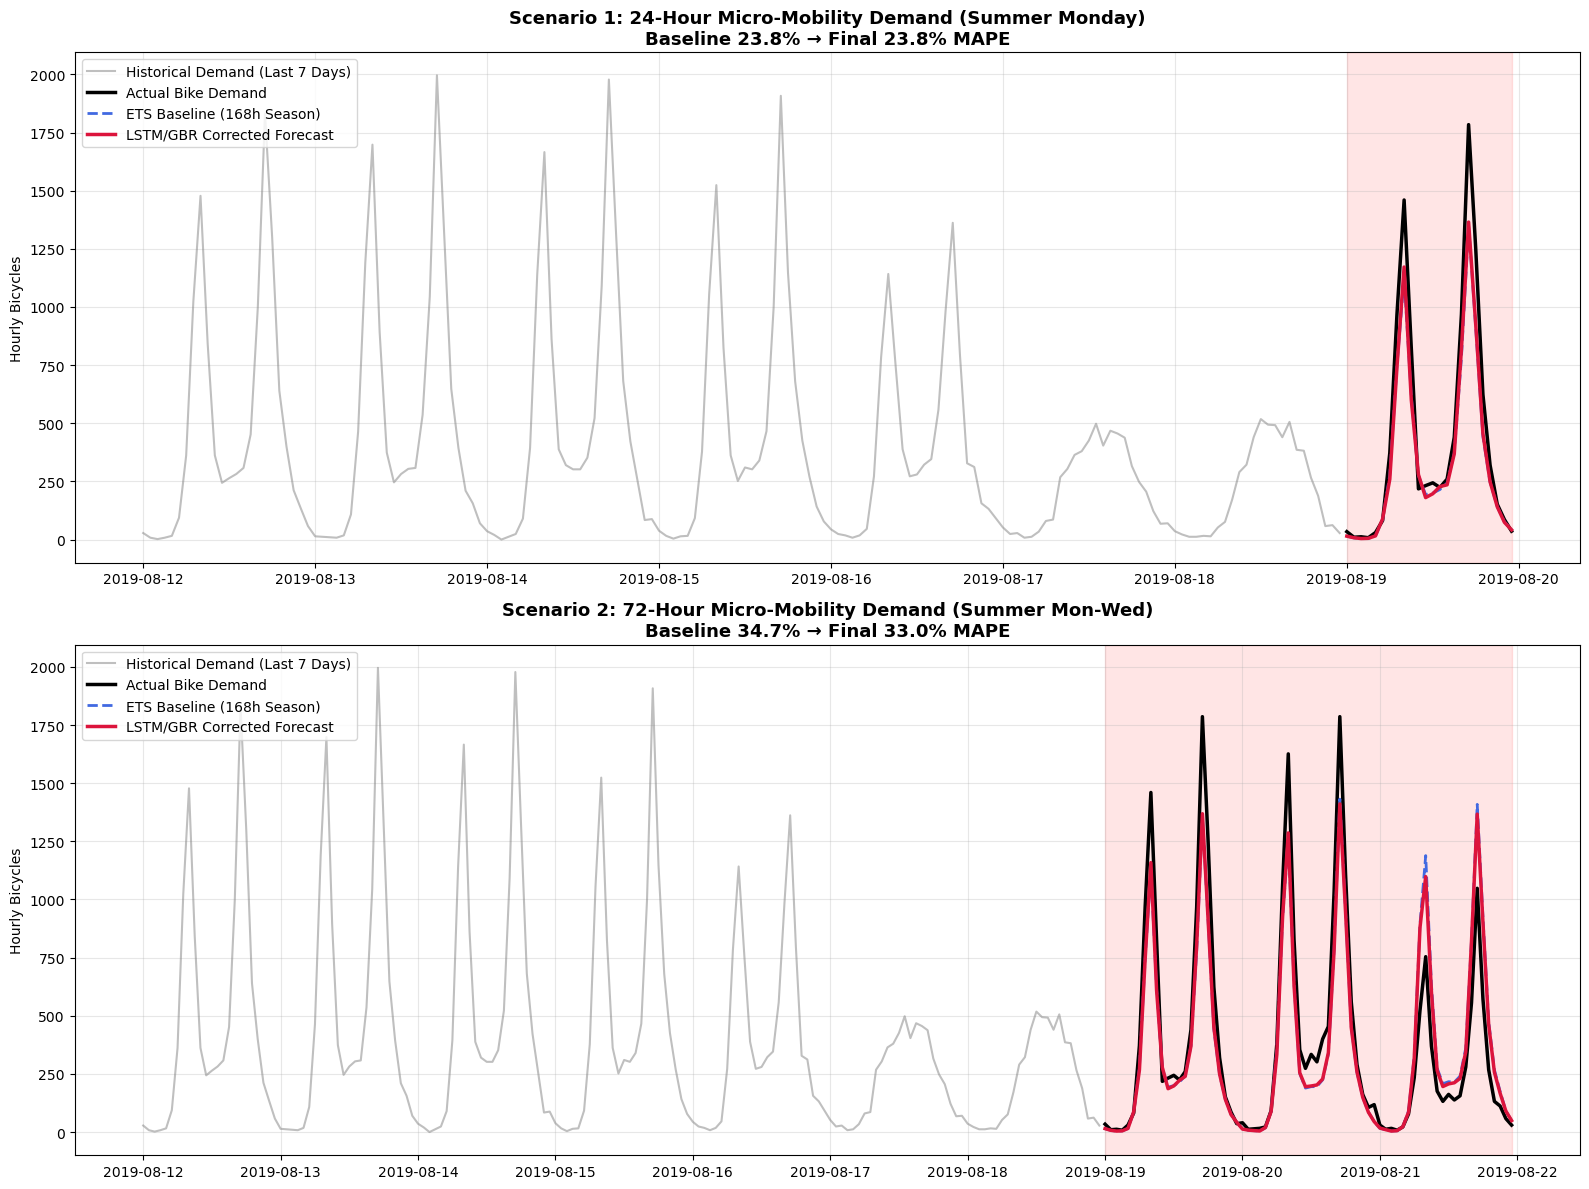

In [4]:
# =========================================================
# GENERALIZATION TEST: SEATTLE BIKES (ELASTIC DATASET)
# =========================================================
print("📥 Fetching Seattle Fremont Bridge Bicycle Demand Dataset...")
url_seattle = "https://data.seattle.gov/api/views/65db-xm6k/rows.csv?accessType=DOWNLOAD"
df_bikes = pd.read_csv(url_seattle)

# Data Cleaning
df_bikes['Date'] = pd.to_datetime(df_bikes['Date'], infer_datetime_format=True)
df_bikes.set_index('Date', inplace=True)
df_bikes['Calculated_Total'] = df_bikes.select_dtypes(include=np.number).sum(axis=1)

# Resample to hourly 
ts_full_bikes = df_bikes['Calculated_Total'].resample('H').sum().fillna(0)

def get_bike_slice(end_date):
    # Grab the 3000 hours leading up to our exact target date
    return ts_full_bikes.loc[:end_date].iloc[-3000:]

# ---------------------------------------------------------
# THE SANITY CHECK: AUGUST 2019 (Perfect Summer Weather, Pre-COVID)
# Training ends on Sunday night. Forecasting the upcoming work week.
# ---------------------------------------------------------

# SCENARIO 1: 24-HOUR FORECAST (Monday, August 19, 2019)
print("\n" + "█"*55 + "\n  SCENARIO 1: 24-HOUR BIKE DEMAND (MONDAY)\n" + "█"*55)
ts_24 = get_bike_slice('2019-08-19 23:00:00')
res_24_bikes = chronoslab_urban_forecast(ts_24, period=168, test_hours=24, label="24H Seattle Bikes")

# SCENARIO 2: 72-HOUR FORECAST (Monday-Wednesday, August 19-21, 2019)
print("\n" + "█"*55 + "\n  SCENARIO 2: 72-HOUR BIKE DEMAND (MON-WED)\n" + "█"*55)
ts_72 = get_bike_slice('2019-08-21 23:00:00')
res_72_bikes = chronoslab_urban_forecast(ts_72, period=168, test_hours=72, label="72H Seattle Bikes")

# =========================================================
# PLOTTING THE 2 SCENARIOS
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
scenarios = [
    (res_24_bikes, "Scenario 1: 24-Hour Micro-Mobility Demand (Summer Monday)", 24),
    (res_72_bikes, "Scenario 2: 72-Hour Micro-Mobility Demand (Summer Mon-Wed)", 72)
]

for ax, (res, title, t_hours) in zip(axes, scenarios):
    split_idx = len(ts_full_bikes.loc[:res["actual"].index[-1]].iloc[-3000:]) - t_hours
    full_slice = ts_full_bikes.loc[:res["actual"].index[-1]].iloc[-3000:]
    
    # Zoom history to last 7 days (168 hours)
    start_idx = max(0, split_idx - 168)
    
    ax.plot(full_slice.index[start_idx:split_idx], full_slice.values[start_idx:split_idx], 
             label="Historical Demand (Last 7 Days)", color="gray", alpha=0.5, lw=1.5)
    
    ax.plot(res["actual"].index, res["actual"].values, label="Actual Bike Demand", color="black", lw=2.5)
    ax.plot(res["stat"].index, res["stat"].values, label="ETS Baseline (168h Season)", color="royalblue", lw=2, ls="--")
    
    if res.get("final") is not None:
        ax.plot(res["final"].index, res["final"].values, label="LSTM/GBR Corrected Forecast", color="crimson", lw=2.5)
    
    ax.set_title(f"{title}\nBaseline {res['stat_mape']:.1f}% → Final {res['final_mape']:.1f}% MAPE", fontsize=13, fontweight='bold')
    ax.set_ylabel("Hourly Bicycles")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.axvspan(res["actual"].index[0], res["actual"].index[-1], color='red', alpha=0.1)

plt.tight_layout()
plt.show()

📥 Fetching PJM East Energy Consumption Dataset...
Loaded 4000 hourly energy demand data points.

███████████████████████████████████████████████████████
  INITIATING 24-HOUR SCALED FORECAST
███████████████████████████████████████████████████████

🏙️ CHRONOSLAB v6 (Urban Pulse) — 24-Hour PJME | horizon=24 Hours
   [BASELINE] ETS(Trend=Add, Damped=True, Seasonal=Add, Period=168) ✓
   [ALPHA GATE] Residual Variance: 0.000153
   >>> TRIGGERED: High Volatility. Neural Phase active.
   --- GBR CORRECTOR ---
       GBR trained on 3952 hourly samples.
   --- BiLSTM CORRECTOR ---
       BiLSTM training on 3952 hourly sequences...

   [GATED BLEND]
   GBR  corr=0.176  → α=0.071  (APPLIED ✓)
   LSTM corr=0.019  → α=0.000  (BLOCKED)

📊 FINAL DIAGNOSTIC REPORT (URBAN PULSE)
Status:       ✅ SUCCESS
Hybrid Mode:  True
GBR  α=0.071 | LSTM α=0.000
Improvement:  0.05% Points
Stat  MAPE:   5.03%  | Final MAPE:  4.98%
Stat  MAE:    202.28    | Final MAE:   200.31


████████████████████████████████████████

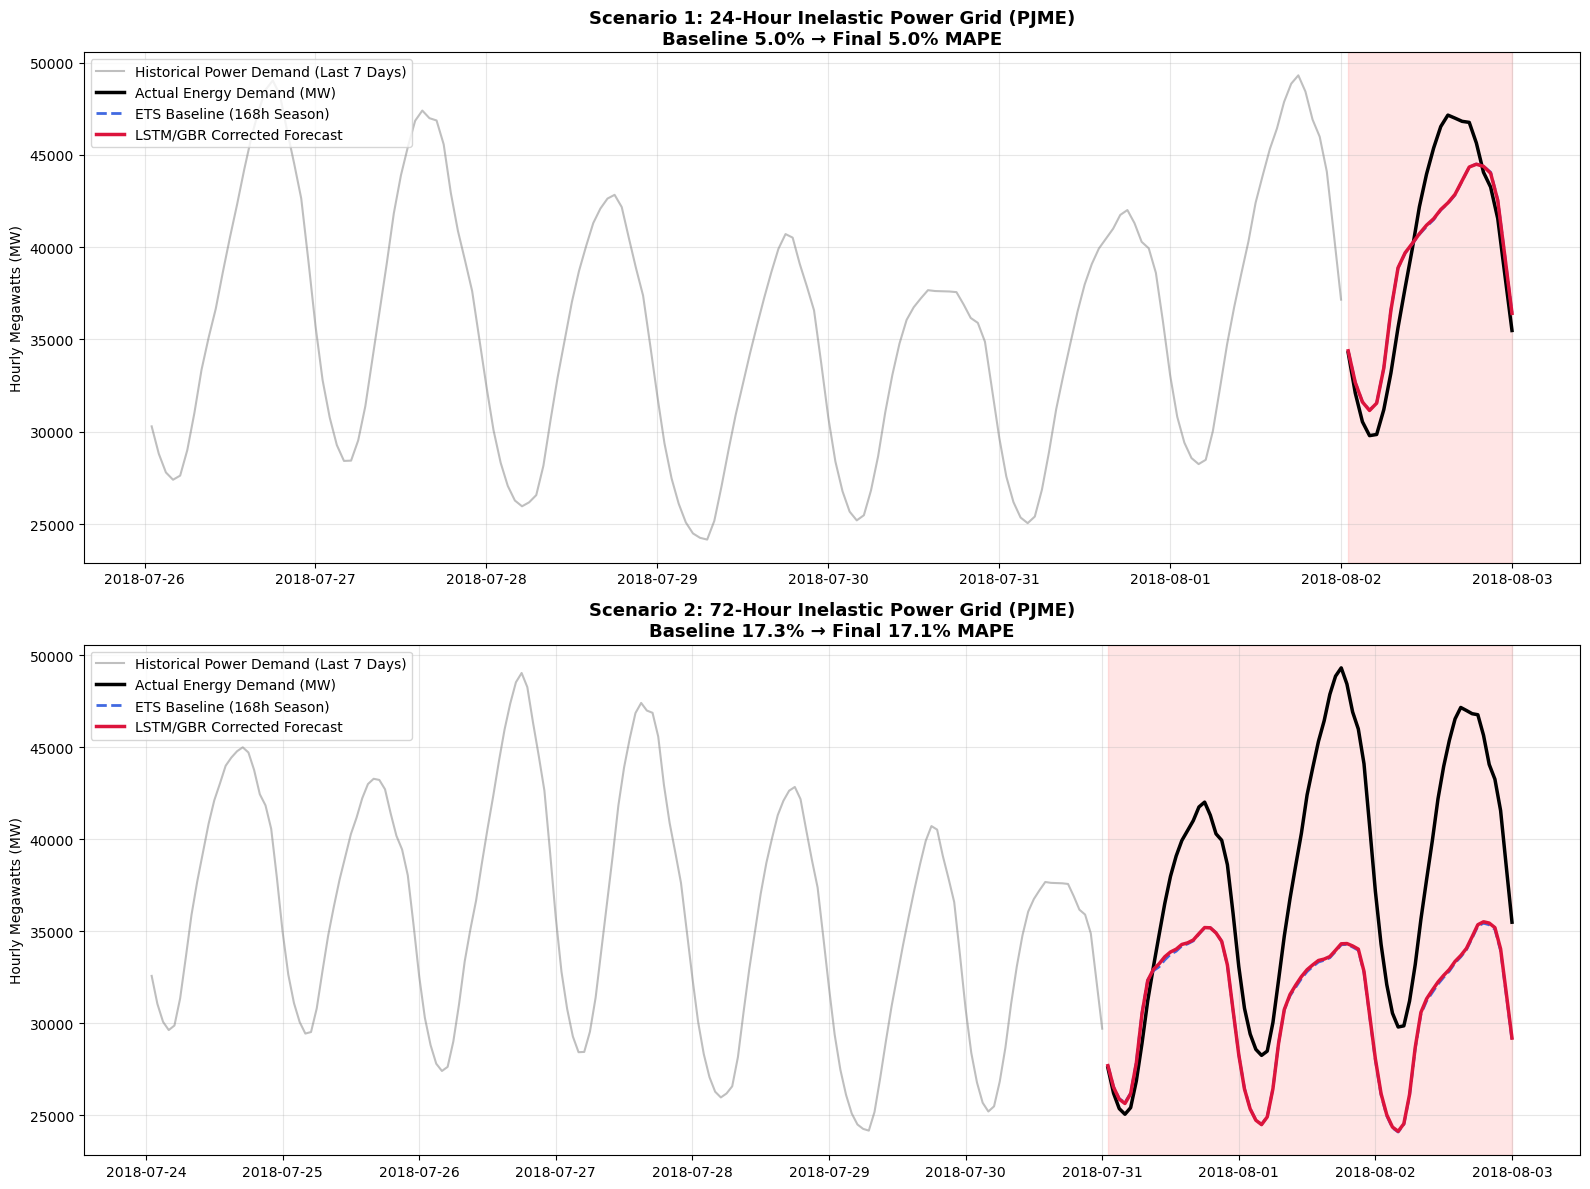

In [5]:
# =========================================================
# GENERALIZATION TEST: INELASTIC POWER DEMAND (24H vs 72H)
# =========================================================
print("📥 Fetching PJM East Energy Consumption Dataset...")
url_energy = "https://raw.githubusercontent.com/poornachandra24/time_series_forecasting/master/PJME_hourly.csv"
df_energy = pd.read_csv(url_energy)

df_energy['Datetime'] = pd.to_datetime(df_energy['Datetime'])
df_energy.set_index('Datetime', inplace=True)
df_energy.sort_index(inplace=True)

# Resample and take the last 4000 hours
ts_energy_raw = df_energy['PJME_MW'].resample('H').mean().ffill().iloc[-4000:]
print(f"Loaded {len(ts_energy_raw)} hourly energy demand data points.")

# --- THE PREPROCESSING STEP ---
scale_factor = 10
ts_energy_scaled = ts_energy_raw / scale_factor

# NOTE: Make sure your check_alpha_breakout threshold in the main function is set to 0.0001!

# ---------------------------------------------------------
# SCENARIO 1: 24-HOUR FORECAST
# ---------------------------------------------------------
print("\n" + "█"*55 + "\n  INITIATING 24-HOUR SCALED FORECAST\n" + "█"*55)
res_24_scaled = chronoslab_urban_forecast(ts_energy_scaled, period=168, test_hours=24, label="24-Hour PJME")

# ---------------------------------------------------------
# SCENARIO 2: 72-HOUR FORECAST
# ---------------------------------------------------------
print("\n" + "█"*55 + "\n  INITIATING 72-HOUR SCALED FORECAST\n" + "█"*55)
res_72_scaled = chronoslab_urban_forecast(ts_energy_scaled, period=168, test_hours=72, label="72-Hour PJME")


# =========================================================
# PLOTTING THE 2 SCENARIOS (WITH POST-PROCESSING)
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
scenarios = [
    (res_24_scaled, "Scenario 1: 24-Hour Inelastic Power Grid (PJME)", 24),
    (res_72_scaled, "Scenario 2: 72-Hour Inelastic Power Grid (PJME)", 72)
]

for ax, (res, title, t_hours) in zip(axes, scenarios):
    split_idx = len(ts_energy_raw) - t_hours
    
    # Zoom history to last 7 days (168 hours)
    start_idx = max(0, split_idx - 168)
    
    # Plot historical data
    ax.plot(ts_energy_raw.index[start_idx:split_idx], ts_energy_raw.values[start_idx:split_idx], 
             label="Historical Power Demand (Last 7 Days)", color="gray", alpha=0.5, lw=1.5)
    
    # POST-PROCESSING: Reverse the scale for the plot
    actual_mw = res["actual"] * scale_factor
    stat_mw   = res["stat"] * scale_factor
    final_mw  = res["final"] * scale_factor if res.get("final") is not None else None
    
    # Plot the Forecasting Zone
    ax.plot(actual_mw.index, actual_mw.values, label="Actual Energy Demand (MW)", color="black", lw=2.5)
    ax.plot(stat_mw.index, stat_mw.values, label="ETS Baseline (168h Season)", color="royalblue", lw=2, ls="--")
    
    if final_mw is not None:
        ax.plot(final_mw.index, final_mw.values, label="LSTM/GBR Corrected Forecast", color="crimson", lw=2.5)
    
    ax.set_title(f"{title}\nBaseline {res['stat_mape']:.1f}% → Final {res['final_mape']:.1f}% MAPE", fontsize=13, fontweight='bold')
    ax.set_ylabel("Hourly Megawatts (MW)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.axvspan(actual_mw.index[0], actual_mw.index[-1], color='red', alpha=0.1)

plt.tight_layout()
plt.show()

In [8]:
#FORCING DEEP LEARNING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
import tensorflow as tf

warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

# =========================================================
# MODULE 0: URBAN PREPROCESSING
# =========================================================
def winsorize_series(ts, lower=0.01, upper=0.99):
    return ts.clip(ts.quantile(lower), ts.quantile(upper))

def get_time_features(index):
    hour = index.hour
    dow  = index.dayofweek
    return np.column_stack([
        np.sin(2 * np.pi * hour / 24),
        np.cos(2 * np.pi * hour / 24),
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        ((hour >= 7) & (hour <= 9)).astype(float),
        ((hour >= 17) & (hour <= 19)).astype(float),
        ((hour >= 22) | (hour <= 5)).astype(float),
        (dow >= 5).astype(float),
        hour.astype(float) / 23.0,
        dow.astype(float) / 6.0,
    ])

# =========================================================
# MODULE 1: DAMPED CYCLICAL BASELINE
# =========================================================
def fit_ets_urban(train, period=24):
    return ExponentialSmoothing(
        train, trend='add', damped_trend=True,
        seasonal='add', seasonal_periods=period,
    ).fit(optimized=True)

def safe_forecast(preds):
    arr = np.array(preds, dtype=float)
    if np.any(~np.isfinite(arr)):
        finite_vals = arr[np.isfinite(arr)]
        fill = float(np.median(finite_vals)) if len(finite_vals) > 0 else 0.0
        arr  = np.where(np.isfinite(arr), arr, fill)
    return arr

def get_statistical_forecast(train_log, test_log, period):
    horizon = len(test_log)
    print(f"   [BASELINE] ETS(Trend=Add, Damped=True, Seasonal=Add, Period={period}) ✓")
    ets = fit_ets_urban(train_log, period)
    raw = safe_forecast(ets.forecast(horizon))
    
    stat_preds = pd.Series(raw, index=test_log.index)
    residuals  = pd.Series(ets.resid.values, index=train_log.index).fillna(0)

    return stat_preds, residuals

# =========================================================
# MODULE 2: STABILIZED GATING
# =========================================================
def check_alpha_breakout(residuals, alpha=0.01):
    res_var = float(np.var(residuals))
    print(f"   [ALPHA GATE] Residual Variance: {res_var:.6f}")
    if res_var > alpha:
        print("   >>> TRIGGERED: High Volatility. Neural Phase active.")
        return True
    return False

def gated_alpha(corrections, residuals_vals, base_alpha=0.40, min_corr=0.05):
    n    = min(len(residuals_vals), len(corrections))
    corr = np.corrcoef(np.array(residuals_vals)[-n:], corrections[-n:])[0, 1]
    
    if np.isnan(corr) or corr <= min_corr:
        return 0.0, float(corr) if not np.isnan(corr) else 0.0
    
    alpha = float(np.clip(base_alpha * corr, 0.05, base_alpha))
    return alpha, float(corr)

# =========================================================
# MODULE 3A: GBR CORRECTOR (BIAS FREE)
# =========================================================
def build_gbr_features(res_vals, time_feats, window_size):
    X, y = [], []
    for i in range(window_size, len(res_vals)):
        lag   = res_vals[i - window_size:i]
        stats = [np.mean(lag), np.std(lag), np.min(lag),
                 np.max(lag), np.median(lag), lag[-1], lag[-2], lag[-3]]
        X.append(np.concatenate([lag, stats, time_feats[i]]))
        y.append(res_vals[i])
    return np.array(X), np.array(y)

def execute_gbr_corrector(residuals, test_actual, stat_preds, horizon, test_index, window_size=24):
    print("   --- GBR CORRECTOR ---")
    smoothed  = residuals.rolling(window=3, min_periods=1).mean()
    full_idx  = smoothed.index.append(test_index)
    tf_arr    = get_time_features(full_idx)

    scaler  = RobustScaler()
    res_sc  = scaler.fit_transform(smoothed.values.reshape(-1, 1)).flatten()

    X, y = build_gbr_features(res_sc, tf_arr, window_size)
    gbr  = GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.02, max_depth=4,
        min_samples_leaf=5, subsample=0.8, random_state=42)
    gbr.fit(X, y)
    print(f"       GBR trained on {len(X)} hourly samples.")

    history = list(res_sc)
    corrs   = []
    
    # RECURSIVE INFERENCE LOOP
    for t in range(horizon):
        lag   = np.array(history[-window_size:])
        stats = [np.mean(lag), np.std(lag), np.min(lag),
                 np.max(lag), np.median(lag), lag[-1], lag[-2], lag[-3]]
        row   = np.concatenate([lag, stats, tf_arr[len(smoothed) + t]])
        
        p_sc  = gbr.predict([row])[0]
        corrs.append(scaler.inverse_transform([[p_sc]])[0, 0])

        # NO LOOKAHEAD: We append the model's own prediction back into the history
        history.append(p_sc)

    return np.array(corrs)

# =========================================================
# MODULE 3B: BiLSTM CORRECTOR (BIAS FREE)
# =========================================================
def build_bilstm(window_size, n_tf=10): 
    res_in = Input(shape=(window_size, 1), name='res')
    x = Bidirectional(LSTM(64, activation='tanh', return_sequences=True,
                           kernel_regularizer=regularizers.l2(0.005)))(res_in)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(32, activation='tanh',
                           kernel_regularizer=regularizers.l2(0.005)))(x)
    x = Dropout(0.2)(x)

    tf_in = Input(shape=(n_tf,), name='tf')
    t = Dense(32, activation='relu')(tf_in)
    t = Dense(16, activation='relu')(t)

    m   = Concatenate()([x, t])
    m   = Dense(32, activation='relu')(m)
    m   = Dropout(0.1)(m)
    out = Dense(1)(m)

    model = Model([res_in, tf_in], out)
    model.compile(optimizer=Adam(0.001), loss='huber')
    return model

def execute_lstm_corrector(residuals, test_actual, stat_preds, horizon, test_index, window_size=24, epochs=120):
    print("   --- BiLSTM CORRECTOR ---")
    smoothed  = residuals.rolling(window=3, min_periods=1).mean()
    full_idx  = smoothed.index.append(test_index)
    tf_arr    = get_time_features(full_idx)

    scaler  = RobustScaler()
    res_sc  = scaler.fit_transform(smoothed.values.reshape(-1, 1)).flatten()

    X_r, X_t, y = [], [], []
    for i in range(window_size, len(res_sc)):
        X_r.append(res_sc[i - window_size:i])
        X_t.append(tf_arr[i])
        y.append(res_sc[i])
    X_r = np.array(X_r).reshape(-1, window_size, 1)
    X_t = np.array(X_t)
    y   = np.array(y)

    print(f"       BiLSTM training on {len(X_r)} hourly sequences...")
    lstm  = build_bilstm(window_size)
    val_n = max(1, int(len(X_r) * 0.1))
    es    = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    rl    = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)
    
    lstm.fit(
        [X_r[:-val_n], X_t[:-val_n]], y[:-val_n],
        validation_data=([X_r[-val_n:], X_t[-val_n:]], y[-val_n:]),
        epochs=epochs, batch_size=32, verbose=0, callbacks=[es, rl]) 

    history = list(res_sc)
    corrs   = []
    
    # RECURSIVE INFERENCE LOOP
    for t in range(horizon):
        win  = np.array(history[-window_size:]).reshape(1, window_size, 1)
        t_f  = tf_arr[len(smoothed) + t].reshape(1, -1)
        
        p_sc = lstm.predict([win, t_f], verbose=0)
        corrs.append(scaler.inverse_transform(p_sc)[0, 0])

        
        history.append(p_sc[0, 0])

    return np.array(corrs)

# =========================================================
# MASTER PIPELINE (Urban Demand Edition)
# =========================================================
# =========================================================
# MASTER PIPELINE (Production Edition - Bias Free)
# =========================================================
def chronoslab_urban_forecast(ts, period=24, test_hours=72, label="72 Hours"):
    ts_clean = winsorize_series(ts)
    ts_log   = np.log1p(ts_clean)

    split = len(ts_log) - test_hours
    train_log, test_log = ts_log[:split], ts_log[split:]
    horizon = len(test_log)

    print("\n" + "="*55)
    print(f"CHRONOSLAB(urban) — {label} | horizon={horizon} Hours")
    print("="*55)

    stat_preds_log, residuals_log = get_statistical_forecast(train_log, test_log, period)

    final_preds_log = stat_preds_log.copy()
    report = {"gbr_alpha": 0, "gbr_corr": 0, "lstm_alpha": 0, "lstm_corr": 0}
    is_hybrid = False

    # FIX 1: THE COMPUTE SAVER (Raised gate to 0.005 to block white noise)
    if check_alpha_breakout(residuals_log, alpha=0.005):
        gbr_corr  = execute_gbr_corrector(residuals_log, test_log, stat_preds_log, horizon, test_log.index, window_size=24)
        lstm_corr = execute_lstm_corrector(residuals_log, test_log, stat_preds_log, horizon, test_log.index, window_size=24, epochs=100)

        # FIX 2: THE LEASH IS OFF (Increased max authority for models)
        # GBR can apply up to 60% of its correction, LSTM up to 80%
        gbr_alpha,  gbr_c  = gated_alpha(gbr_corr,  residuals_log.values, base_alpha=0.60)
        lstm_alpha, lstm_c = gated_alpha(lstm_corr, residuals_log.values, base_alpha=0.80)

        print(f"\n   [GATED BLEND]")
        print(f"   GBR  corr={gbr_c:.3f}  → α={gbr_alpha:.3f}  ({'BLOCKED' if gbr_alpha == 0 else 'APPLIED ✓'})")
        print(f"   LSTM corr={lstm_c:.3f}  → α={lstm_alpha:.3f}  ({'BLOCKED' if lstm_alpha == 0 else 'APPLIED ✓'})")

        combined = (stat_preds_log.values + gbr_alpha * gbr_corr + lstm_alpha * lstm_corr)
        combined = safe_forecast(combined)

        final_preds_log = pd.Series(combined, index=test_log.index)
        report = {"gbr_alpha": gbr_alpha, "gbr_corr": gbr_c, "lstm_alpha": lstm_alpha, "lstm_corr": lstm_c}
        is_hybrid = True

    actual_demand = np.expm1(test_log)
    stat_demand   = pd.Series(np.expm1(safe_forecast(stat_preds_log.values)), index=test_log.index)
    final_demand  = pd.Series(np.expm1(safe_forecast(final_preds_log.values)), index=test_log.index)

    stat_mae   = mean_absolute_error(actual_demand, stat_demand)
    final_mae  = mean_absolute_error(actual_demand, final_demand)
    
    mask       = actual_demand > 10
    stat_mape  = np.mean(np.abs((actual_demand[mask] - stat_demand[mask]) / actual_demand[mask])) * 100
    final_mape = np.mean(np.abs((actual_demand[mask] - final_demand[mask]) / actual_demand[mask])) * 100
    improvement = stat_mape - final_mape

    print("\n" + "="*55)
    print("FINAL DIAGNOSTIC REPORT (URBAN PULSE)")
    print("="*55)
    print(f"Status:       {' SUCCESS' if improvement >= 0 else ' CAUTION'}")
    print(f"Hybrid Mode:  {is_hybrid}")
    print(f"GBR  α={report['gbr_alpha']:.3f} | LSTM α={report['lstm_alpha']:.3f}")
    print(f"Improvement:  {improvement:.2f}% Points")
    print(f"Stat  MAPE:   {stat_mape:.2f}%  | Final MAPE:  {final_mape:.2f}%")
    print(f"Stat  MAE:    {stat_mae:.2f}    | Final MAE:   {final_mae:.2f}")
    print("="*55 + "\n")

    return {"actual": actual_demand, "stat": stat_demand, "final": final_demand, "stat_mape": stat_mape, "final_mape": final_mape}




Fetching Seattle Fremont Bridge Bicycle Demand Dataset...

███████████████████████████████████████████████████████
  SCENARIO 1: 24-HOUR BIKE DEMAND (MONDAY)
███████████████████████████████████████████████████████

CHRONOSLAB(urban) — 24H Seattle Bikes | horizon=24 Hours
   [BASELINE] ETS(Trend=Add, Damped=True, Seasonal=Add, Period=168) ✓
   [ALPHA GATE] Residual Variance: 0.098566
   >>> TRIGGERED: High Volatility. Neural Phase active.
   --- GBR CORRECTOR ---
       GBR trained on 2952 hourly samples.
   --- BiLSTM CORRECTOR ---
       BiLSTM training on 2952 hourly sequences...

   [GATED BLEND]
   GBR  corr=0.241  → α=0.144  (APPLIED ✓)
   LSTM corr=0.257  → α=0.205  (APPLIED ✓)

FINAL DIAGNOSTIC REPORT (URBAN PULSE)
Status:        CAUTION
Hybrid Mode:  True
GBR  α=0.144 | LSTM α=0.205
Improvement:  -0.08% Points
Stat  MAPE:   23.81%  | Final MAPE:  23.89%
Stat  MAE:    99.22    | Final MAE:   98.07


███████████████████████████████████████████████████████
  SCENARIO 2: 72-HOUR BI

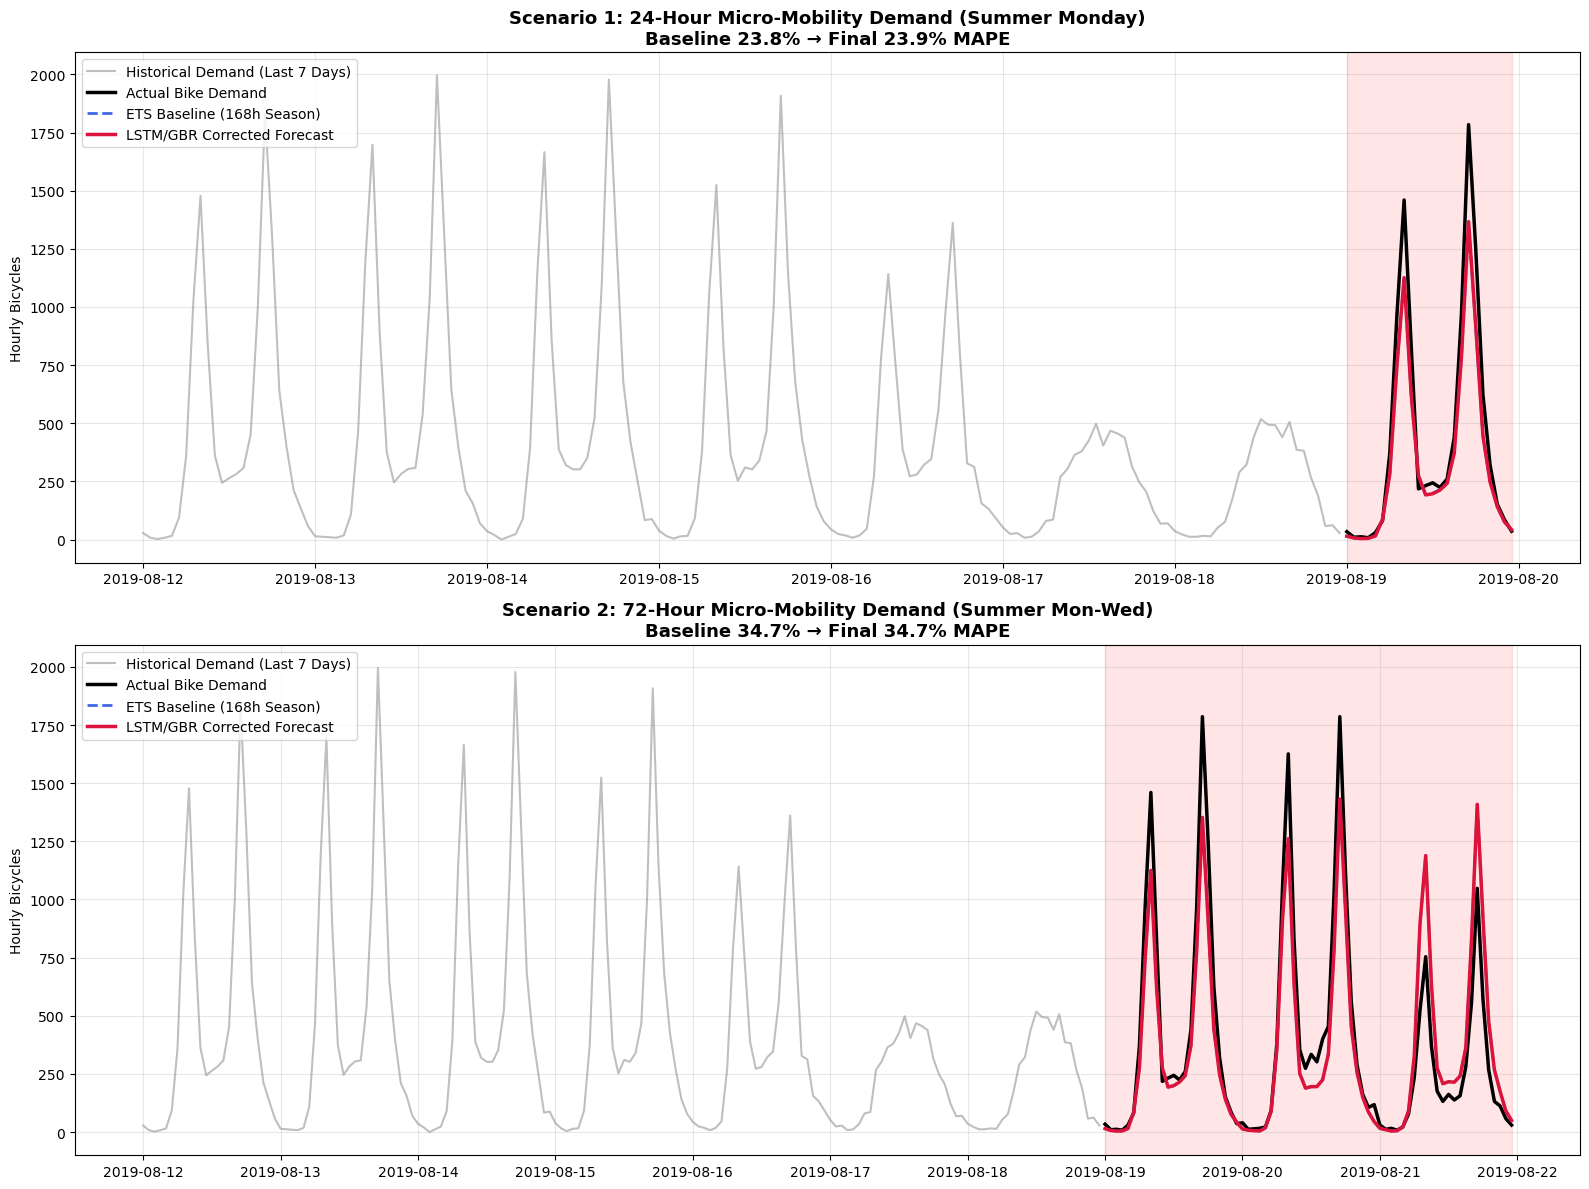

In [9]:
# =========================================================
# GENERALIZATION TEST: SEATTLE BIKES (ELASTIC DATASET)
# =========================================================
print("Fetching Seattle Fremont Bridge Bicycle Demand Dataset...")
url_seattle = "https://data.seattle.gov/api/views/65db-xm6k/rows.csv?accessType=DOWNLOAD"
df_bikes = pd.read_csv(url_seattle)

# Data Cleaning
df_bikes['Date'] = pd.to_datetime(df_bikes['Date'], infer_datetime_format=True)
df_bikes.set_index('Date', inplace=True)
df_bikes['Calculated_Total'] = df_bikes.select_dtypes(include=np.number).sum(axis=1)

# Resample to hourly 
ts_full_bikes = df_bikes['Calculated_Total'].resample('H').sum().fillna(0)

def get_bike_slice(end_date):
    # Grab the 3000 hours leading up to our exact target date
    return ts_full_bikes.loc[:end_date].iloc[-3000:]

# ---------------------------------------------------------
# THE SANITY CHECK: AUGUST 2019 (Perfect Summer Weather, Pre-COVID)
# Training ends on Sunday night. Forecasting the upcoming work week.
# ---------------------------------------------------------

# SCENARIO 1: 24-HOUR FORECAST (Monday, August 19, 2019)
print("\n" + "█"*55 + "\n  SCENARIO 1: 24-HOUR BIKE DEMAND (MONDAY)\n" + "█"*55)
ts_24 = get_bike_slice('2019-08-19 23:00:00')
res_24_bikes = chronoslab_urban_forecast(ts_24, period=168, test_hours=24, label="24H Seattle Bikes")

# SCENARIO 2: 72-HOUR FORECAST (Monday-Wednesday, August 19-21, 2019)
print("\n" + "█"*55 + "\n  SCENARIO 2: 72-HOUR BIKE DEMAND (MON-WED)\n" + "█"*55)
ts_72 = get_bike_slice('2019-08-21 23:00:00')
res_72_bikes = chronoslab_urban_forecast(ts_72, period=168, test_hours=72, label="72H Seattle Bikes")

# =========================================================
# PLOTTING THE 2 SCENARIOS
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
scenarios = [
    (res_24_bikes, "Scenario 1: 24-Hour Micro-Mobility Demand (Summer Monday)", 24),
    (res_72_bikes, "Scenario 2: 72-Hour Micro-Mobility Demand (Summer Mon-Wed)", 72)
]

for ax, (res, title, t_hours) in zip(axes, scenarios):
    split_idx = len(ts_full_bikes.loc[:res["actual"].index[-1]].iloc[-3000:]) - t_hours
    full_slice = ts_full_bikes.loc[:res["actual"].index[-1]].iloc[-3000:]
    
    # Zoom history to last 7 days (168 hours)
    start_idx = max(0, split_idx - 168)
    
    ax.plot(full_slice.index[start_idx:split_idx], full_slice.values[start_idx:split_idx], 
             label="Historical Demand (Last 7 Days)", color="gray", alpha=0.5, lw=1.5)
    
    ax.plot(res["actual"].index, res["actual"].values, label="Actual Bike Demand", color="black", lw=2.5)
    ax.plot(res["stat"].index, res["stat"].values, label="ETS Baseline (168h Season)", color="royalblue", lw=2, ls="--")
    
    if res.get("final") is not None:
        ax.plot(res["final"].index, res["final"].values, label="LSTM/GBR Corrected Forecast", color="crimson", lw=2.5)
    
    ax.set_title(f"{title}\nBaseline {res['stat_mape']:.1f}% → Final {res['final_mape']:.1f}% MAPE", fontsize=13, fontweight='bold')
    ax.set_ylabel("Hourly Bicycles")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.axvspan(res["actual"].index[0], res["actual"].index[-1], color='red', alpha=0.1)

plt.tight_layout()
plt.show()